# Importing necessary modules and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


# Dataset loading

In [2]:
df=pd.read_csv('1429_1.csv')
df.head()

/var/folders/z3/b1qy845929gd42tn63d50dgm0000gn/T/ipykernel_1401/4116593429.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('1429_1.csv')


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


# Data Cleaning 

In [3]:
df.isna().sum()

id                          0
name                     6760
asins                       2
brand                       0
categories                  0
keys                        0
manufacturer                0
reviews.date               39
reviews.dateAdded       10621
reviews.dateSeen            0
reviews.didPurchase     34659
reviews.doRecommend       594
reviews.id              34659
reviews.numHelpful        529
reviews.rating             33
reviews.sourceURLs          0
reviews.text                1
reviews.title               6
reviews.userCity        34660
reviews.userProvince    34660
reviews.username            7
dtype: int64

In [4]:
df = df[['reviews.text', 'reviews.rating', 'reviews.title']].dropna()
df

,reviews.text,reviews.rating,reviews.title
0,This product so far has not disappointed. My c...,5.0,Kindle
1,great for beginner or experienced person. Boug...,5.0,very fast
2,Inexpensive tablet for him to use and learn on...,5.0,Beginner tablet for our 9 year old son.
3,I've had my Fire HD 8 two weeks now and I love...,4.0,Good!!!
4,I bought this for my grand daughter when she c...,5.0,Fantastic Tablet for kids
...,...,...,...
34655,This is not appreciably faster than any other ...,3.0,Not appreciably faster than any other 1.8A cha...
34656,Amazon should include this charger with the Ki...,1.0,Should be included
34657,Love my Kindle Fire but I am really disappoint...,1.0,Disappointing Charger
34658,I was surprised to find it did not come with a...,1.0,Not worth the money


In [5]:
df.isna().sum()

reviews.text      0
reviews.rating    0
reviews.title     0
dtype: int64

In [6]:
df['combined_text'] = df['reviews.title'] + ' ' + df['reviews.text']
df

,reviews.text,reviews.rating,reviews.title,combined_text
0,This product so far has not disappointed. My c...,5.0,Kindle,Kindle This product so far has not disappointe...
1,great for beginner or experienced person. Boug...,5.0,very fast,very fast great for beginner or experienced pe...
2,Inexpensive tablet for him to use and learn on...,5.0,Beginner tablet for our 9 year old son.,Beginner tablet for our 9 year old son. Inexpe...
3,I've had my Fire HD 8 two weeks now and I love...,4.0,Good!!!,Good!!! I've had my Fire HD 8 two weeks now an...
4,I bought this for my grand daughter when she c...,5.0,Fantastic Tablet for kids,Fantastic Tablet for kids I bought this for my...
...,...,...,...,...
34655,This is not appreciably faster than any other ...,3.0,Not appreciably faster than any other 1.8A cha...,Not appreciably faster than any other 1.8A cha...
34656,Amazon should include this charger with the Ki...,1.0,Should be included,Should be included Amazon should include this ...
34657,Love my Kindle Fire but I am really disappoint...,1.0,Disappointing Charger,Disappointing Charger Love my Kindle Fire but ...
34658,I was surprised to find it did not come with a...,1.0,Not worth the money,Not worth the money I was surprised to find it...


In [7]:
df = df[['combined_text', 'reviews.rating']]
df

,combined_text,reviews.rating
0,Kindle This product so far has not disappointe...,5.0
1,very fast great for beginner or experienced pe...,5.0
2,Beginner tablet for our 9 year old son. Inexpe...,5.0
3,Good!!! I've had my Fire HD 8 two weeks now an...,4.0
4,Fantastic Tablet for kids I bought this for my...,5.0
...,...,...
34655,Not appreciably faster than any other 1.8A cha...,3.0
34656,Should be included Amazon should include this ...,1.0
34657,Disappointing Charger Love my Kindle Fire but ...,1.0
34658,Not worth the money I was surprised to find it...,1.0


# Label Creation for ratings

In [8]:
def label_sentiment(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive
df['label'] = df['reviews.rating'].apply(label_sentiment)
df

/var/folders/z3/b1qy845929gd42tn63d50dgm0000gn/T/ipykernel_1401/530356400.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['reviews.rating'].apply(label_sentiment)


,combined_text,reviews.rating,label
0,Kindle This product so far has not disappointe...,5.0,2
1,very fast great for beginner or experienced pe...,5.0,2
2,Beginner tablet for our 9 year old son. Inexpe...,5.0,2
3,Good!!! I've had my Fire HD 8 two weeks now an...,4.0,2
4,Fantastic Tablet for kids I bought this for my...,5.0,2
...,...,...,...
34655,Not appreciably faster than any other 1.8A cha...,3.0,1
34656,Should be included Amazon should include this ...,1.0,0
34657,Disappointing Charger Love my Kindle Fire but ...,1.0,0
34658,Not worth the money I was surprised to find it...,1.0,0


# Data splitting

In [9]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train ,y_test= train_test_split(df['combined_text'],
                                                    df['label'],
                                                    test_size=0.2, 
                                                    random_state=0)

# Bert applying 
# Tokenisation

In [10]:
from transformers import AutoTokenizer

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(x_train.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(x_test.tolist(), truncation=True, padding=True, max_length=128)

# Pytorch tensors

In [12]:
import torch
from torch.utils.data import TensorDataset

# Tokenized outputs → PyTorch tensors
input_ids = torch.tensor(train_encodings['input_ids'])
attention_mask = torch.tensor(train_encodings['attention_mask'])
labels = torch.tensor(y_train.values)

# Create dataset
train_dataset = TensorDataset(input_ids, attention_mask, labels)

# Create test dataset 
input_ids = torch.tensor(test_encodings['input_ids'])
attention_mask = torch.tensor(test_encodings['attention_mask'])
labels = torch.tensor(y_test.values)

test_dataset = TensorDataset(input_ids, attention_mask, labels)

In [13]:
import accelerate
print(accelerate.__version__)

1.9.0


In [14]:
from transformers import BertForSequenceClassification

# Load model with 3 output labels (adjust if your task is binary/multi-class)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)





Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Data Loader

In [15]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
import torch

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

batch_size = 16  # You can adjust this depending on memory

# Training DataLoader (shuffles data each epoch)
train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

# Testing DataLoader (keeps order)
test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)


# Optimizer

In [16]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch

num_epochs=3

# Initialize optimizer
optimizer = AdamW(model.parameters(), 
                 lr=2e-5,       # Default BERT learning rate
                 eps=1e-8,      # Prevents division by zero
                 weight_decay=0.01)  # Regularization

# Calculate total steps
total_steps = len(train_dataloader) * num_epochs

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),  # 10% warmup
    num_training_steps=total_steps
)

In [ ]:
import torch
print(torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"))


mps


# Model Training 

In [18]:
'''epochs = num_epochs  # We already set this to 3

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()  # Puts the model in training mode
    
    total_loss = 0

    for batch in train_dataloader:
        # Move batch to device (GPU if available)
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass (BERT returns loss & logits)
        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
            labels=b_labels
        )

        loss = outputs.loss  # CrossEntropy loss
        total_loss += loss.item()

        # Backward pass (compute gradients)
        loss.backward()

        # Update model weights
        optimizer.step()

        # Update learning rate according to scheduler
        scheduler.step()

    avg_loss = total_loss / len(train_dataloader)
    print(f"Average training loss: {avg_loss:.4f}")'''

'epochs = num_epochs  # We already set this to 3\n\nfor epoch in range(epochs):\n    print(f"\nEpoch {epoch+1}/{epochs}")\n    model.train()  # Puts the model in training mode\n\n    total_loss = 0\n\n    for batch in train_dataloader:\n        # Move batch to device (GPU if available)\n        b_input_ids = batch[0].to(device)\n        b_attention_mask = batch[1].to(device)\n        b_labels = batch[2].to(device)\n\n        # Reset gradients\n        optimizer.zero_grad()\n\n        # Forward pass (BERT returns loss & logits)\n        outputs = model(\n            input_ids=b_input_ids,\n            attention_mask=b_attention_mask,\n            labels=b_labels\n        )\n\n        loss = outputs.loss  # CrossEntropy loss\n        total_loss += loss.item()\n\n        # Backward pass (compute gradients)\n        loss.backward()\n\n        # Update model weights\n        optimizer.step()\n\n        # Update learning rate according to scheduler\n        scheduler.step()\n\n    avg_loss =

# Saving the trained data

In [19]:
# Save the model
model.save_pretrained("./sentiment_model")

# Save the tokenizer (important so you use the same preprocessing later)
tokenizer.save_pretrained("./sentiment_model")


('./sentiment_model/tokenizer_config.json',
 './sentiment_model/special_tokens_map.json',
 './sentiment_model/vocab.txt',
 './sentiment_model/added_tokens.json',
 './sentiment_model/tokenizer.json')

# Load model & tokenizer for inference

In [55]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

# Load model & tokenizer from saved directory
model = BertForSequenceClassification.from_pretrained("./sentiment_model")
tokenizer = BertTokenizer.from_pretrained("./sentiment_model")

# Use the same device as before (MPS for Mac, CUDA for GPU, CPU if nothing else)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()  # set to evaluation mode


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

# for immediate testing /// deployment 

In [68]:
import torch

# Function to predict sentiment
def predict_sentiment(review_text):
    # Tokenize the input text (same way as during training)
    encoding = tokenizer(
        review_text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move tokenized data to the same device as the model
    encoding = {key: val.to(device) for key, val in encoding.items()}

    # Put model in evaluation mode
    model.eval()

    # Get predictions without tracking gradients
    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    # Map numeric label back to string
    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return label_map[predicted_class]


In [70]:
print(predict_sentiment("This product is amazing!"))
print(predict_sentiment("It was okay, not great."))
print(predict_sentiment("Worst purchase ever."))


Negative
Neutral
Negative


# testing remaing 20% dataset

In [45]:
'''from sklearn.metrics import classification_report

# Map numeric labels to text labels
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Convert y_test numeric values to text labels
y_test_labels = [label_map[label] for label in y_test]

# Store predictions
predictions = []
for review in x_test:
    pred_label = predict_sentiment(review)  # Returns text label
    predictions.append(pred_label)

# Show performance report
print(classification_report(
    y_test_labels,
    predictions,
    target_names=["Negative", "Neutral", "Positive"]
))'''


'from sklearn.metrics import classification_report\n\n# Map numeric labels to text labels\nlabel_map = {0: "Negative", 1: "Neutral", 2: "Positive"}\n\n# Convert y_test numeric values to text labels\ny_test_labels = [label_map[label] for label in y_test]\n\n# Store predictions\npredictions = []\nfor review in x_test:\n    pred_label = predict_sentiment(review)  # Returns text label\n    predictions.append(pred_label)\n\n# Show performance report\nprint(classification_report(\n    y_test_labels,\n    predictions,\n    target_names=["Negative", "Neutral", "Positive"]\n))'

# Visulisation of model performance

In [46]:
'''import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test_labels, predictions, labels=["Negative", "Neutral", "Positive"])

# Plot heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()'''


'import seaborn as sns\nfrom sklearn.metrics import confusion_matrix\n\n# Create confusion matrix\ncm = confusion_matrix(y_test_labels, predictions, labels=["Negative", "Neutral", "Positive"])\n\n# Plot heatmap\nsns.heatmap(cm, annot=True, fmt="d", cmap="Blues",\n            xticklabels=["Negative", "Neutral", "Positive"],\n            yticklabels=["Negative", "Neutral", "Positive"])\nplt.xlabel("Predicted")\nplt.ylabel("Actual")\nplt.title("Confusion Matrix")\nplt.show()'

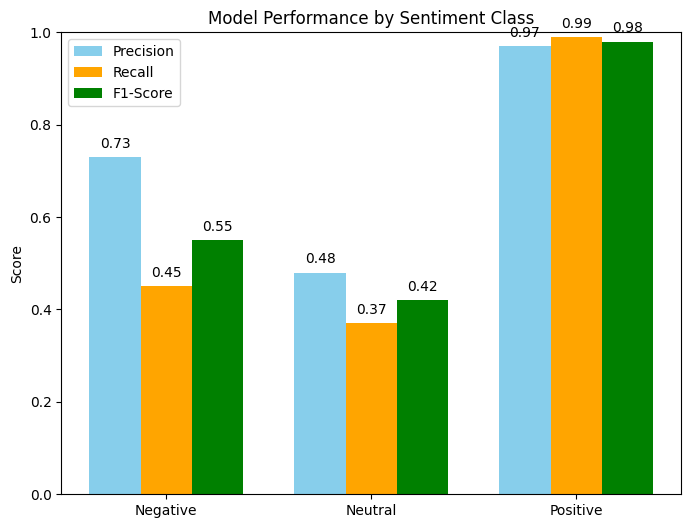

In [25]:
# results
classes = ["Negative", "Neutral", "Positive"]
precision = [0.73, 0.48, 0.97]
recall = [0.45, 0.37, 0.99]
f1_score = [0.55, 0.42, 0.98]

x = np.arange(len(classes))  
width = 0.25  

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width, precision, width, label="Precision", color='skyblue')
ax.bar(x, recall, width, label="Recall", color='orange')
ax.bar(x + width, f1_score, width, label="F1-Score", color='green')

ax.set_ylabel("Score")
ax.set_title("Model Performance by Sentiment Class")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1)
ax.legend()

# Annotate bars
for bars in [precision, recall, f1_score]:
    for i, val in enumerate(bars):
        ax.text(i + (-width if bars==precision else width if bars==f1_score else 0), 
                val + 0.02, f"{val:.2f}", ha='center')

plt.show()


# Deployment

In [28]:
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json')

In [47]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# Load your saved model and tokenizer
model = BertForSequenceClassification.from_pretrained("saved_model")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Detect device: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

model.to(device)
model.eval()

# Define prediction function
def predict_sentiment(review_text):
    # Tokenize input
    encoding = tokenizer(
        review_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    # Move input to the same device as model
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return label_map[predicted_class]


# ✅ Test
print(predict_sentiment("This product is amazing!"))
print(predict_sentiment("It was okay, not great."))
print(predict_sentiment("Worst purchase ever."))


Using device: mps
Negative
Neutral
Negative


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/module.py:1541: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [71]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import gradio as gr

# Load tokenizer and trained model
model_path = "./saved_model"   # Change this to your saved model folder
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Use CPU or GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Prediction function
def predict_sentiment(review_text):
    encoding = tokenizer(
        review_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return label_map[predicted_class]

# Gradio UI
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a product review..."),
    outputs="text",
    title="BERT Sentiment Analysis",
    description="Enter a review and see if it's Positive, Neutral, or Negative."
)

# Launch app
iface.launch(server_name="127.0.0.1", server_port=7861, share=True)


OSError: Cannot find empty port in range: 7861-7861. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.